# GFCC-CNN: Gammatone Frequency Cepstral Coefficients + CNN

Converted from MFCC-CNN. Uses gammatone filterbank (GFCC) instead of MFCC for feature extraction.

In [1]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from scipy.fftpack import dct
from scipy.signal import gammatone


In [2]:
ROOT_PATH = "/kaggle/input/datasets/artharking/torgod/TorgoD"  # change this

SR = 16000
N_GFCC = 20           # number of GFCC coefficients (same as N_MFCC was)
N_FILTERS = 64        # number of gammatone filters
FRAME_LEN = 0.025     # 25 ms
HOP_LEN = 0.010       # 10 ms
LOW_FREQ = 100.0      # lowest center frequency for gammatone bank

FIXED_LEN = 250      # time frames (important for CNN)

BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3


In [3]:
# label_map = {
#     "Normal": 0,
#     "Low": 3,
#     "Mid": 2,
#     "High": 1,
#     "Very_Low": 4
# }
# NUM_CLASSES = len(label_map)

# ✅ MODIFIED: Class order — Normal → High → Mid → Low → Very_Low
label_map = {
          
    "Low":  0,
    "Medium":1,
    "VeryLow": 2
}
NUM_CLASSES = len(label_map)

## 2. GFCC Feature Extraction

GFCC uses a **gammatone filterbank** (which models the human auditory system) instead of mel filterbanks used by MFCC. Steps:
1. Frame the audio signal
2. Apply gammatone filters (IIR, ERB-spaced center frequencies)
3. Compute log energy in each filter channel
4. Apply DCT to decorrelate → GFCC coefficients

In [4]:
def erb_space(low_freq, high_freq, n):
    """Generate ERB-spaced center frequencies for gammatone filterbank."""
    ear_q = 9.26449
    min_bw = 24.7
    cf_array = -(ear_q * min_bw) + np.exp(
        np.arange(1, n + 1) * (-np.log(high_freq + ear_q * min_bw) + np.log(low_freq + ear_q * min_bw)) / n
    ) * (high_freq + ear_q * min_bw)
    return cf_array


def gammatone_filterbank(signal, sr, n_filters=64, low_freq=100.0):
    """
    Apply a gammatone filterbank to a signal.
    Returns: (n_filters, n_samples) array of filter outputs.
    """
    high_freq = sr / 2.0
    center_freqs = erb_space(low_freq, high_freq, n_filters)
    output = np.zeros((n_filters, len(signal)))
    for i, cf in enumerate(center_freqs):
        b, a = gammatone(cf, 'iir', fs=sr)
        from scipy.signal import lfilter
        output[i] = np.abs(lfilter(b, a, signal))
    return output


def extract_gfcc(file_path):
    """
    Extract GFCC features from an audio file.
    Replaces extract_mfcc() — same interface, drop-in swap.
    """
    y, sr = librosa.load(file_path, sr=SR)

    frame_length = int(FRAME_LEN * sr)   # samples per frame
    hop_length   = int(HOP_LEN  * sr)   # hop between frames

    # 1. Apply gammatone filterbank to the full signal
    gt_output = gammatone_filterbank(y, sr, n_filters=N_FILTERS, low_freq=LOW_FREQ)
    # gt_output: (N_FILTERS, n_samples)

    # 2. Frame the filter outputs and compute log energy per frame
    n_frames = 1 + (gt_output.shape[1] - frame_length) // hop_length
    frames = np.zeros((N_FILTERS, n_frames))
    for t in range(n_frames):
        start = t * hop_length
        end   = start + frame_length
        frame_energy = np.sum(gt_output[:, start:end] ** 2, axis=1)
        frames[:, t] = np.log(frame_energy + 1e-10)

    # 3. Apply DCT to get cepstral coefficients
    gfcc = dct(frames, type=2, axis=0, norm='ortho')[:N_GFCC, :]
    # gfcc: (N_GFCC, n_frames)

    # 4. Fix length (pad or truncate to FIXED_LEN)
    if gfcc.shape[1] < FIXED_LEN:
        pad_width = FIXED_LEN - gfcc.shape[1]
        gfcc = np.pad(gfcc, ((0, 0), (0, pad_width)), mode='constant')
    else:
        gfcc = gfcc[:, :FIXED_LEN]

    return gfcc  # shape: (N_GFCC, FIXED_LEN)


## 3. Precompute & Save GFCC Features

In [5]:
SAVE_PATH = "/kaggle/working/gfcc_features"
os.makedirs(SAVE_PATH, exist_ok=True)

def save_gfcc_dataset(root_dir, split):
    split_path = os.path.join(root_dir, split)

    for severity in os.listdir(split_path):
        sev_path = os.path.join(split_path, severity)

        if not os.path.isdir(sev_path):
            continue

        save_sev_path = os.path.join(SAVE_PATH, split, severity)
        os.makedirs(save_sev_path, exist_ok=True)

        for file in tqdm(os.listdir(sev_path), desc=f"{split}-{severity}"):
            if not file.endswith(".wav"):
                continue

            file_path = os.path.join(sev_path, file)
            gfcc = extract_gfcc(file_path)

            save_file = os.path.join(save_sev_path, file.replace(".wav", ".npy"))
            np.save(save_file, gfcc)


In [6]:
save_gfcc_dataset(ROOT_PATH, "train")
save_gfcc_dataset(ROOT_PATH, "test")


test-Medium: 100%|██████████| 243/243 [00:24<00:00, 10.07it/s]


## 4. PyTorch Dataset

In [7]:
import torch
from torch.utils.data import Dataset

class GFCCDataset(Dataset):
    def __init__(self, root_dir):
        self.files = []
        self.labels = []

        for severity in os.listdir(root_dir):
            sev_path = os.path.join(root_dir, severity)

            if not os.path.isdir(sev_path):
                continue

            for file in os.listdir(sev_path):
                if file.endswith(".npy"):
                    self.files.append(os.path.join(sev_path, file))
                    self.labels.append(label_map[severity])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        gfcc = np.load(self.files[idx])  # shape: (N_GFCC, FIXED_LEN)
        gfcc  = torch.tensor(gfcc, dtype=torch.float32).unsqueeze(0)  # (1, N_GFCC, FIXED_LEN)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return gfcc, label


In [8]:
train_dataset = GFCCDataset("/kaggle/working/gfcc_features/train")
test_dataset  = GFCCDataset("/kaggle/working/gfcc_features/test")


In [9]:
val_size   = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)


## 5. CNN Model

Architecture is unchanged — GFCC produces the same `(1, N_GFCC, FIXED_LEN)` shaped tensor as MFCC did.

In [10]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 5, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 2),
            nn.ReLU(),
            nn.MaxPool2d((1, 2))
        )

        # Adaptive pooling — avoids manual dimension calc
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 50))

        self.classifier = nn.Sequential(
            nn.Linear(128 * 1 * 50, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


In [12]:
 pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


## 6. Training

In [13]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


In [14]:
import os
import shutil

best_val_acc = 0
save_path = "/tmp/best_model.pth"

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path, _use_new_zipfile_serialization=False)
        print(f"✅ Best model updated! Val Acc: {val_acc:.4f}")

# After training, copy to working directory
shutil.copy(save_path, "./best_model.pth")
print("✅ Model copied to working directory!")


100%|██████████| 72/72 [00:04<00:00, 15.79it/s]


Epoch 1/20: Loss=53.8284, Val Acc=0.7087
✅ Best model updated! Val Acc: 0.7087


100%|██████████| 72/72 [00:03<00:00, 22.75it/s]


Epoch 2/20: Loss=30.8589, Val Acc=0.9055
✅ Best model updated! Val Acc: 0.9055


100%|██████████| 72/72 [00:03<00:00, 22.55it/s]


...

Epoch 18/20: Loss=2.8349, Val Acc=0.9764


100%|██████████| 72/72 [00:03<00:00, 21.76it/s]


Epoch 19/20: Loss=0.5171, Val Acc=0.9685


100%|██████████| 72/72 [00:03<00:00, 21.58it/s]

Epoch 20/20: Loss=0.1224, Val Acc=0.9803
✅ Best model updated! Val Acc: 0.9803
✅ Model copied to working directory!


## 7. Inference

In [15]:
def predict(file_path, model_path="best_model.pth"):
    model = CNNModel()
    model.load_state_dict(torch.load(model_path))
    model.eval()

    gfcc = extract_gfcc(file_path)                              # (N_GFCC, FIXED_LEN)
    gfcc = torch.tensor(gfcc).unsqueeze(0).unsqueeze(0)        # (1, 1, N_GFCC, FIXED_LEN)

    with torch.no_grad():
        output = model(gfcc)
        pred   = torch.argmax(output, dim=1).item()

    inv_map = {v: k for k, v in label_map.items()}
    return inv_map[pred]


## 8. Evaluation on Test Set

In [16]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [17]:
model = CNNModel().to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()


CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 128, kernel_size=(2, 2), stride=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(1, 50))
  (classifier): Sequential(
    (0): Linear(in_features=6400, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [18]:
correct = 0
total = 0

all_preds  = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        preds   = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()
        total   += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = correct / total
print(f"✅ Test Accuracy: {test_acc:.4f}")


100%|██████████| 20/20 [00:00<00:00, 92.06it/s]

✅ Test Accuracy: 0.9969


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=label_map.keys()))



Classification Report:

              precision    recall  f1-score   support

         Low       0.98      0.98      0.98        53
      Medium       1.00      1.00      1.00       243
     VeryLow       1.00      1.00      1.00       344

    accuracy                           1.00       640
   macro avg       0.99      0.99      0.99       640
weighted avg       1.00      1.00      1.00       640



In [20]:
# import pandas as pd

# inv_map = {v: k for k, v in label_map.items()}

# filenames = [os.path.basename(test_dataset.files[i]) for i in range(len(test_dataset))]

# scores = []
# all_preds = []
# all_labels = []

# model.eval()
# with torch.no_grad():
#     for x, y in tqdm(DataLoader(test_dataset, batch_size=32, shuffle=False)):
#         x, y = x.to(device), y.to(device)
#         outputs = model(x)
#         probs = torch.softmax(outputs, dim=1)
#         best_scores = probs.max(dim=1).values
#         preds = torch.argmax(outputs, dim=1)

#         scores.extend(best_scores.cpu().numpy())
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(y.cpu().numpy())

# df = pd.DataFrame({
#     "filename":      filenames,
#     "score":         scores,
#     "predict class": [inv_map[p] for p in all_preds],
#     "actual class":  [inv_map[l] for l in all_labels],
# })

# df.to_excel("/kaggle/working/results.xlsx", index=False)
# print("✅ Saved results.xlsx")

import pandas as pd

inv_map = {v: k for k, v in label_map.items()}

# Class order: Normal → High → Mid → Low → Very_Low
class_order =[ "Low","Medium", "VeryLow"]

filenames  = [os.path.basename(test_dataset.files[i]) for i in range(len(test_dataset))]

all_preds      = []
all_labels     = []
all_raw_scores = []   # raw logits per class
all_softmax    = []   # softmax probabilities per class

model.eval()
with torch.no_grad():
    for x, y in tqdm(DataLoader(test_dataset, batch_size=32, shuffle=False)):
        x, y = x.to(device), y.to(device)
        outputs = model(x)                          # raw logits: (batch, NUM_CLASSES)
        probs   = torch.softmax(outputs, dim=1)     # softmax probabilities
        preds   = torch.argmax(outputs, dim=1)

        all_raw_scores.extend(outputs.cpu().numpy())
        all_softmax.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Build DataFrame
df = pd.DataFrame({"filename": filenames})

# Raw logit score for each class
for cls_name in class_order:
    df[f"score_{cls_name}"] = [row[label_map[cls_name]] for row in all_raw_scores]

# Softmax probability for each class
for cls_name in class_order:
    df[f"prob_{cls_name}"] = [row[label_map[cls_name]] for row in all_softmax]

# Final prediction & actual label
df["predict class"] = [inv_map[p] for p in all_preds]
df["actual class"]  = [inv_map[l] for l in all_labels]

# Save both CSV and Excel
df.to_csv("/kaggle/working/results.csv",   index=False)
df.to_excel("/kaggle/working/results.xlsx", index=False)
print("✅ Saved results.csv and results.xlsx")
print(df.head())


100%|██████████| 20/20 [00:00<00:00, 79.33it/s]


✅ Saved results.csv and results.xlsx
             filename  score_Low  score_Medium  score_VeryLow      prob_Low  \
0  F04-S2-VL-0028.npy   0.053369    -12.768376      18.386581  1.091408e-08   
1  M03-S2-VL-0034.npy  -5.401448     -6.940388      12.517421  1.651711e-08   
2  F04-S1-VL-0022.npy  -2.373648     -5.512145      10.429737  2.751433e-06   
3  F03-S1-VL-0017.npy  -1.273536     -8.308765      13.053699  5.994605e-07   
4  F03-S1-VL-0005.npy  -4.864905     -5.921805      12.178620  3.963609e-08   

    prob_Medium  prob_VeryLow predict class actual class  
0  2.948317e-14      1.000000       VeryLow      VeryLow  
1  3.544710e-09      1.000000       VeryLow      VeryLow  
2  1.192689e-07      0.999997       VeryLow      VeryLow  
3  5.277145e-10      0.999999       VeryLow      VeryLow  
4  1.377479e-08      1.000000       VeryLow      VeryLow  


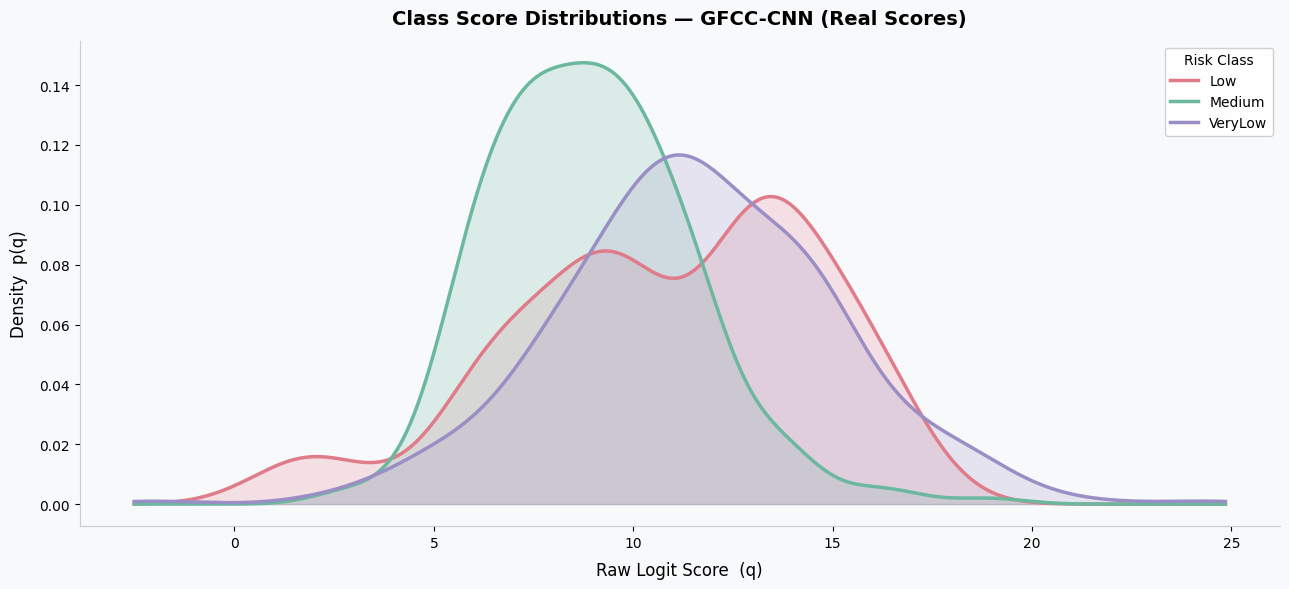

✅ Saved distribution_plot.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Class order: Normal → High → Mid → Low → Very_Low
class_order =[ "Low","Medium", "VeryLow"]
colors = {
    
    "Low":      "#e07b8a",
    "Medium":      "#6bb89e",
    "VeryLow": "#9b8ec4",
}

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#f8f9fb")
ax.set_facecolor("#f8f9fb")

# Compute x-axis range from real scores
all_scores_flat = []
for cls_name in class_order:
    col = f"score_{cls_name}"
    cls_rows = df[df["actual class"] == cls_name][col].values
    all_scores_flat.extend(cls_rows)

x_min = min(all_scores_flat) - 0.5
x_max = max(all_scores_flat) + 0.5
x = np.linspace(x_min, x_max, 600)

# Plot each class using REAL scores from df
for cls_name in class_order:
    col = f"score_{cls_name}"
    cls_scores = df[df["actual class"] == cls_name][col].values
    if len(cls_scores) < 2:
        continue
    kde = gaussian_kde(cls_scores, bw_method=0.35)
    y_vals = kde(x)
    ax.plot(x, y_vals, color=colors[cls_name], linewidth=2.5, label=cls_name, zorder=3)
    ax.fill_between(x, y_vals, alpha=0.20, color=colors[cls_name], zorder=2)

# # Decision boundary at logit = 0
# ax.axvline(0, color="#555", linewidth=1.3, linestyle="--", alpha=0.6, zorder=4)
# ax.text(0.05, ax.get_ylim()[1] * 0.95, "Decision\nBoundary",
        # fontsize=8, color="#444",
        # bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaa", alpha=0.8))

ax.set_xlabel("Raw Logit Score  (q)", fontsize=12, labelpad=8)
ax.set_ylabel("Density  p(q)", fontsize=12, labelpad=8)
ax.set_title("Class Score Distributions — GFCC-CNN (Real Scores)",
             fontsize=14, fontweight="bold", pad=12)
ax.legend(title="Risk Class", fontsize=10, title_fontsize=10,
          framealpha=0.9, edgecolor="#ccc")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ccc")
plt.tight_layout()
plt.savefig("/kaggle/working/distribution_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved distribution_plot.png")


## Single File Prediction (Optional)

In [22]:
# def predict(file_path, model, device):
#     model.eval()
#
#     gfcc = extract_gfcc(file_path)
#     gfcc = torch.tensor(gfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
#
#     with torch.no_grad():
#         output = model(gfcc)
#         pred   = torch.argmax(output, dim=1).item()
#
#     inv_map = {v: k for k, v in label_map.items()}
#     return inv_map[pred]
#
# file = "/kaggle/input/YOUR_DATASET/test/Low/sample.wav"
# print("Prediction:", predict(file, model, device))
